In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/robiulhasanjisan/student-exam-scores-and-study-habits-dataset/student_dataset.csv


# Problem Statement

Many educational institutions struggle to predict student performance accurately due to multiple interacting factors such as study habits, attendance, parental involvement, and access to resources. By leveraging AI and machine learning models, we can predict final exam scores and identify the key factors that most influence academic success. This helps educators make informed decisions, personalize learning, and improve student outcomes.

**Why AI Adoption Matters**
  
* **Data-driven insights:** AI can analyze large datasets and uncover patterns humans might miss.
* **Personalized support:** Helps identify students at risk and tailor interventions.
* **Efficiency:** Automates analysis, saving time for educators and administrators.
* **Continuous improvement:** Models can improve over time with more data, making predictions more accurate.
  
**Objectives of This Notebook**

* **Explore and Understand the Data**
    - Perform exploratory data analysis (EDA) on student demographics, study habits, and academic performance.
* **Feature Engineering**
    - Create meaningful features like interaction scores, composite engagement scores, and polynomial terms to improve model accuracy.
* **Model Development and Evaluation**
   - Train multiple regression models (Linear, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting, XGBoost).
   - Evaluate performance using metrics like R², RMSE, and MAE.
* **Hyperparameter Tuning**
   - Optimize models such as Gradient Boosting to improve prediction accuracy.
* **Feature Importance Analysis**
   - Identify which factors most influence final exam performance.
* **Visualize Insights**
   - Use plots and charts to communicate findings clearly to educators and stakeholders.

# libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Machine learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the dataset

In [3]:
df = pd.read_csv('/kaggle/input/datasets/robiulhasanjisan/student-exam-scores-and-study-habits-dataset/student_dataset.csv')


# Display basic information

In [4]:

print("\nDataset Shape:", df.shape)




Dataset Shape: (6607, 11)


In [5]:
print(df.head())



   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0           23.5        84.2                  Low                 Low   
1           19.7        63.6               Medium                High   
2           24.4        98.4               Medium              Medium   
3           29.6        88.6               Medium                High   
4           19.1        91.5                 High              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                        Yes          7.4             50.3           Medium   
1                        Yes          6.7             83.1              Low   
2                        Yes          8.0             63.5           Medium   
3                        Yes          6.3             57.5           Medium   
4                        Yes          6.2             66.0           Medium   

  Internet_Access  Tutoring_Sessions  Final_Exam_Score  
0             Yes            

In [6]:
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6607 non-null   float64
 1   Attendance                  6607 non-null   float64
 2   Parental_Involvement        6607 non-null   object 
 3   Access_to_Resources         6607 non-null   object 
 4   Extracurricular_Activities  6607 non-null   object 
 5   Sleep_Hours                 6607 non-null   float64
 6   Previous_Scores             6607 non-null   float64
 7   Motivation_Level            6607 non-null   object 
 8   Internet_Access             6607 non-null   object 
 9   Tutoring_Sessions           6607 non-null   int64  
 10  Final_Exam_Score            6607 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 567.9+ KB
None


In [7]:
print(df.describe())

       Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  \
count    6607.000000  6607.000000  6607.000000      6607.000000   
mean       20.472726    79.979068     7.185273        74.716059   
std         5.988729    11.547717     1.290241        14.451962   
min         1.100000    60.000000     4.000000        50.000000   
25%        16.500000    70.000000     6.300000        62.100000   
50%        20.500000    79.800000     7.200000        74.600000   
75%        24.500000    90.200000     8.100000        87.400000   
max        44.000000   100.000000    10.000000       100.000000   

       Tutoring_Sessions  Final_Exam_Score  
count        6607.000000       6607.000000  
mean            1.488119         60.400333  
std             1.216175          8.739400  
min             0.000000         29.700000  
25%             1.000000         54.300000  
50%             1.000000         60.400000  
75%             2.000000         66.600000  
max             8.000000         95.

##  Check for missing values

In [8]:

print(df.isnull().sum())


Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Final_Exam_Score              0
dtype: int64


## Check data types

In [9]:
print(df.dtypes)


Hours_Studied                 float64
Attendance                    float64
Parental_Involvement           object
Access_to_Resources            object
Extracurricular_Activities     object
Sleep_Hours                   float64
Previous_Scores               float64
Motivation_Level               object
Internet_Access                object
Tutoring_Sessions               int64
Final_Exam_Score              float64
dtype: object


# EDA

* **Distribution plots (histograms)** → Check how numerical features are spread (mean, median, skewness).
* **Categorical bar plots** → See frequency of each category (data balance).
* **Correlation heatmap** → Identify relationships between features and target.
* **Boxplots** → Compare how categories affect Final_Exam_Score.
* **Scatter plots + trend lines** → Understand relationships between numeric features and target.

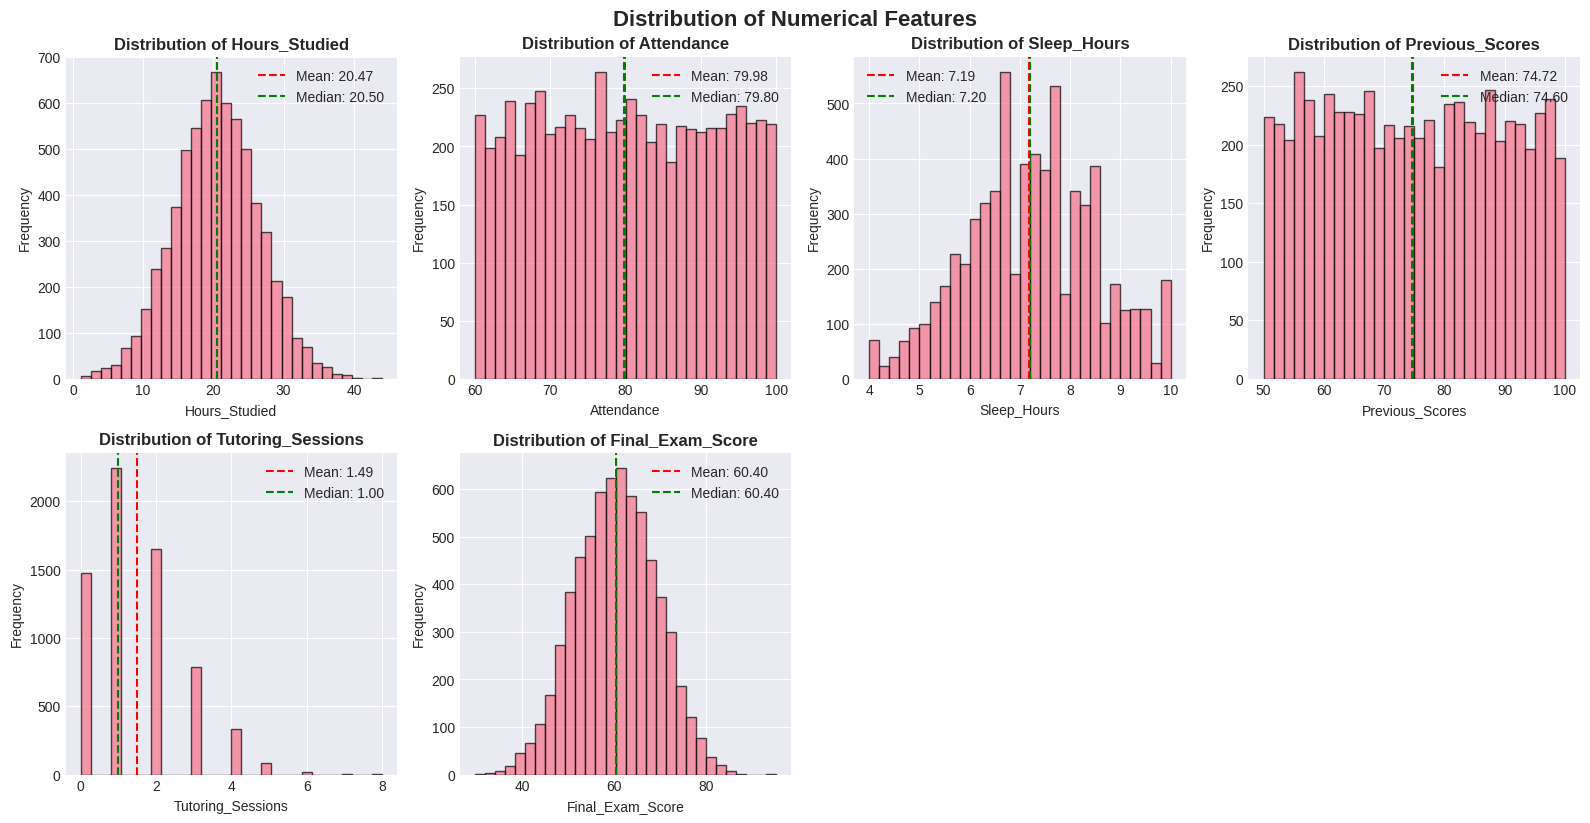

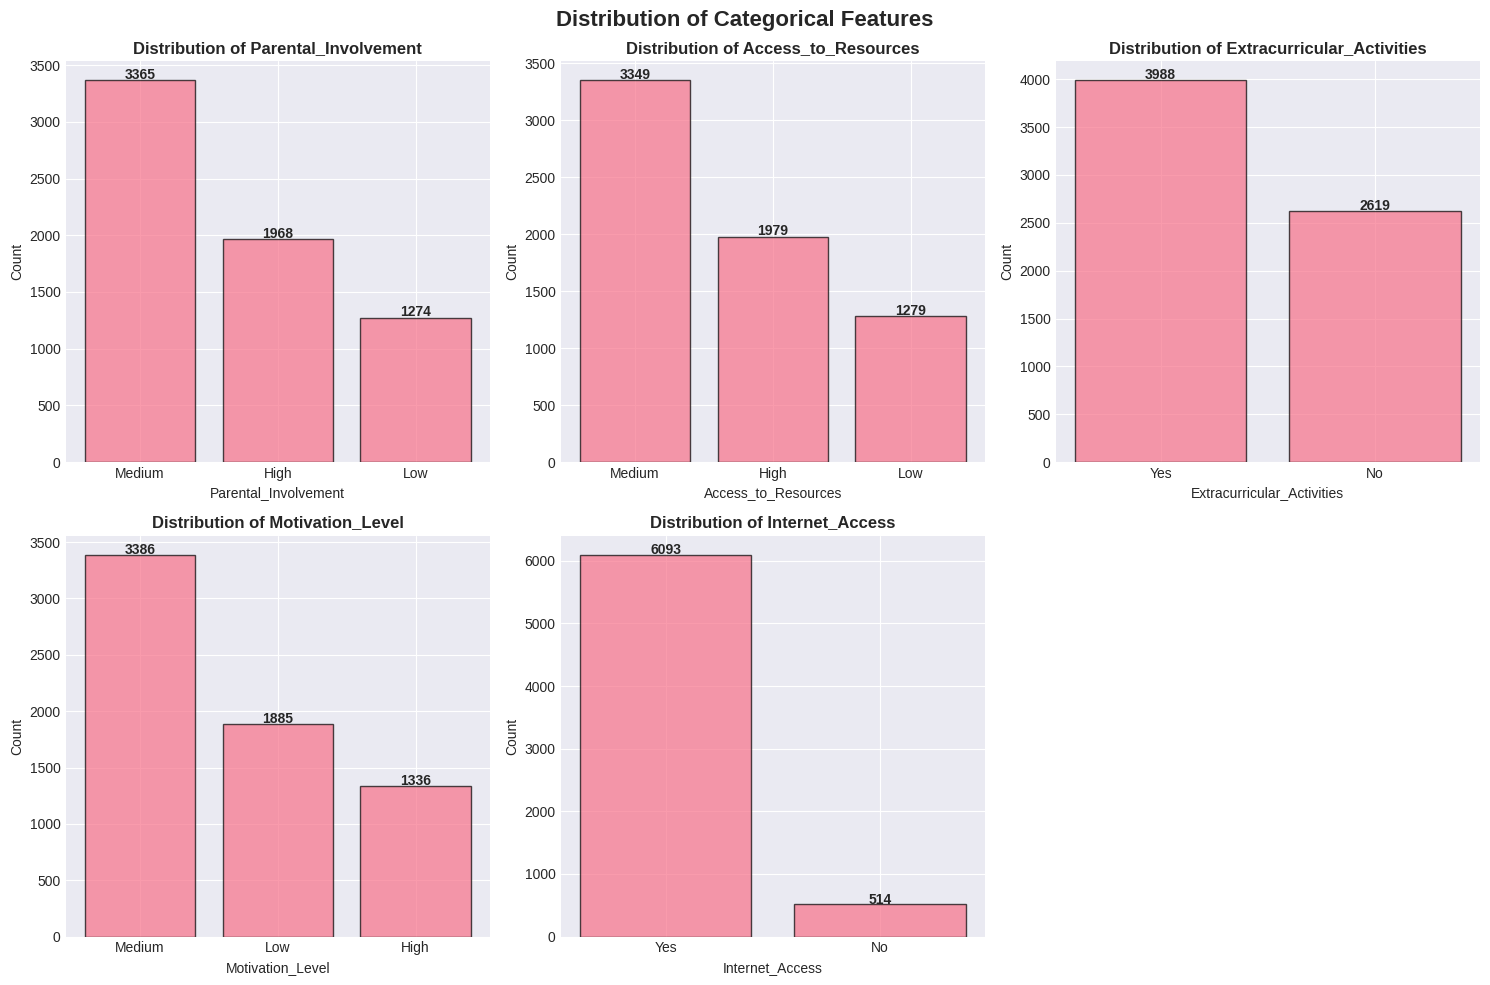

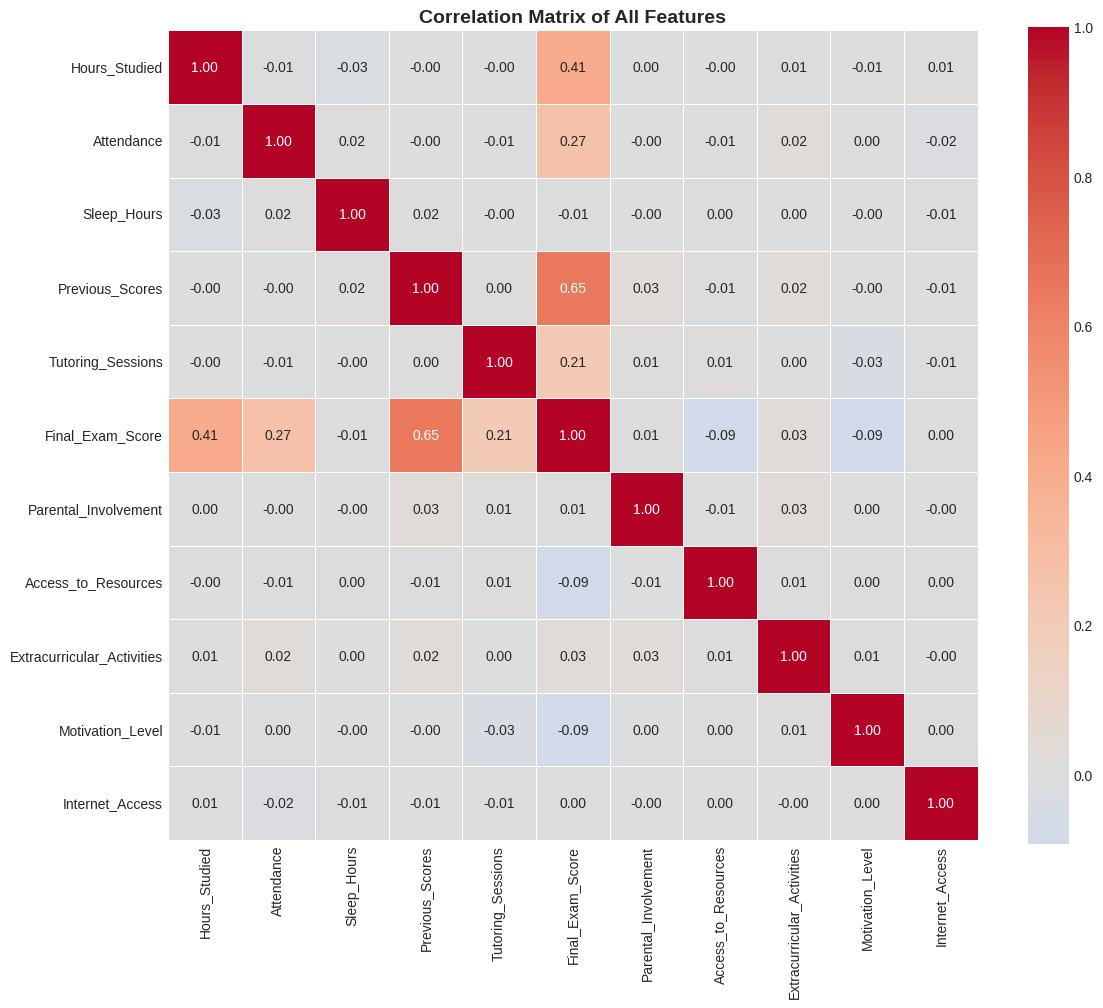


Feature Correlation with Final Exam Score:
Final_Exam_Score              1.000000
Previous_Scores               0.653388
Hours_Studied                 0.409850
Attendance                    0.266152
Tutoring_Sessions             0.207310
Extracurricular_Activities    0.029540
Parental_Involvement          0.009099
Internet_Access               0.003703
Sleep_Hours                  -0.012736
Motivation_Level             -0.089535
Access_to_Resources          -0.092617
Name: Final_Exam_Score, dtype: float64


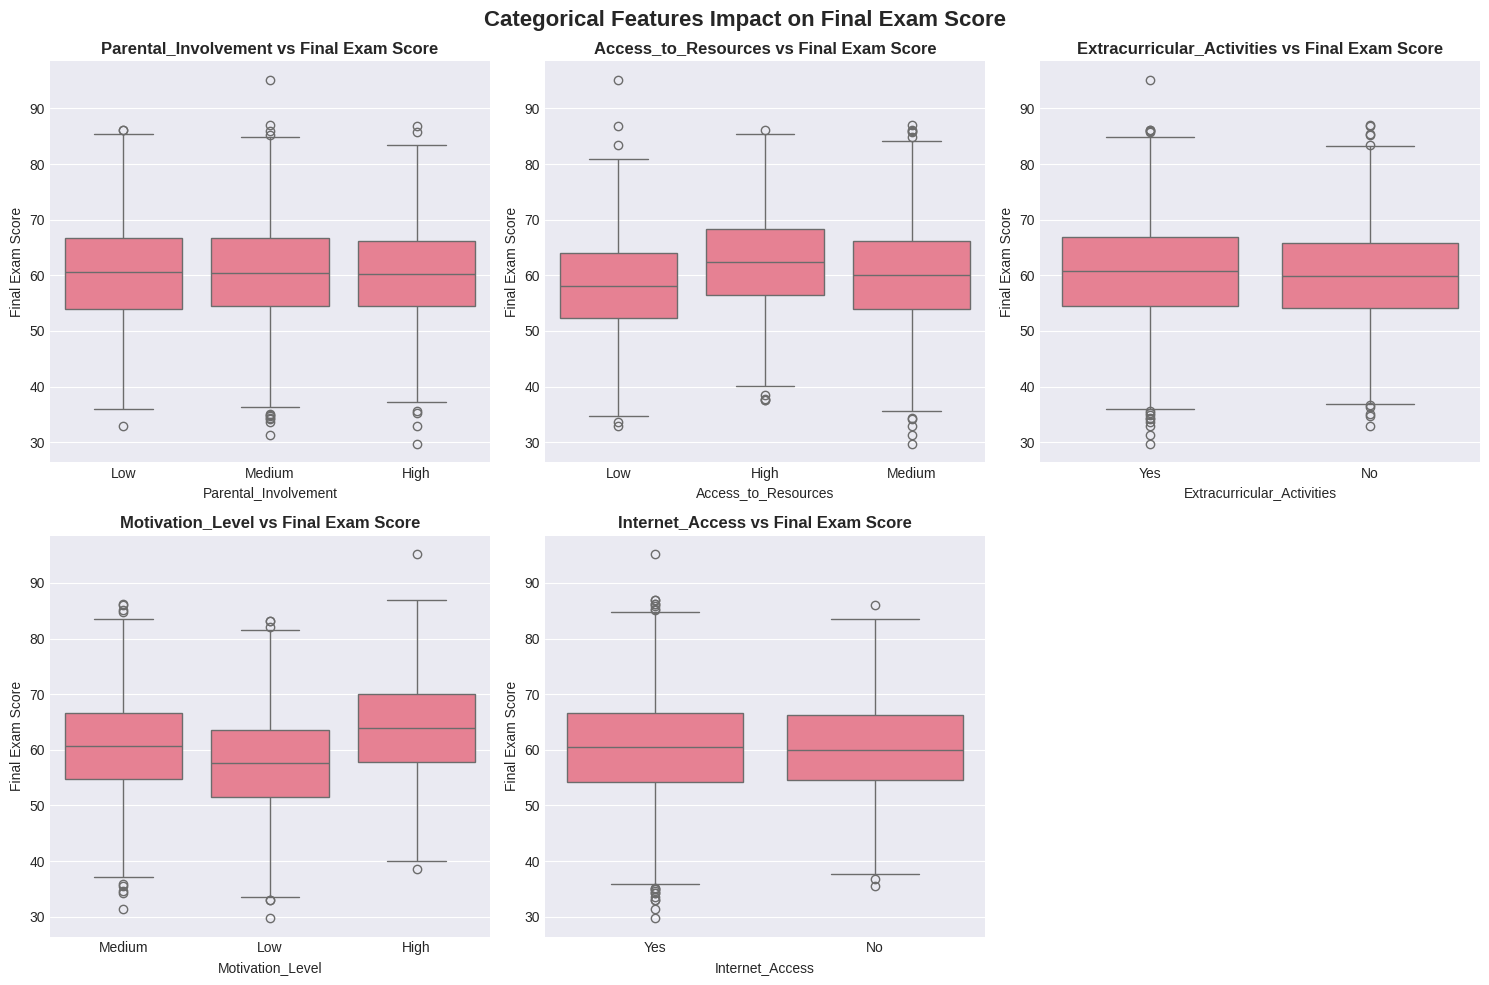

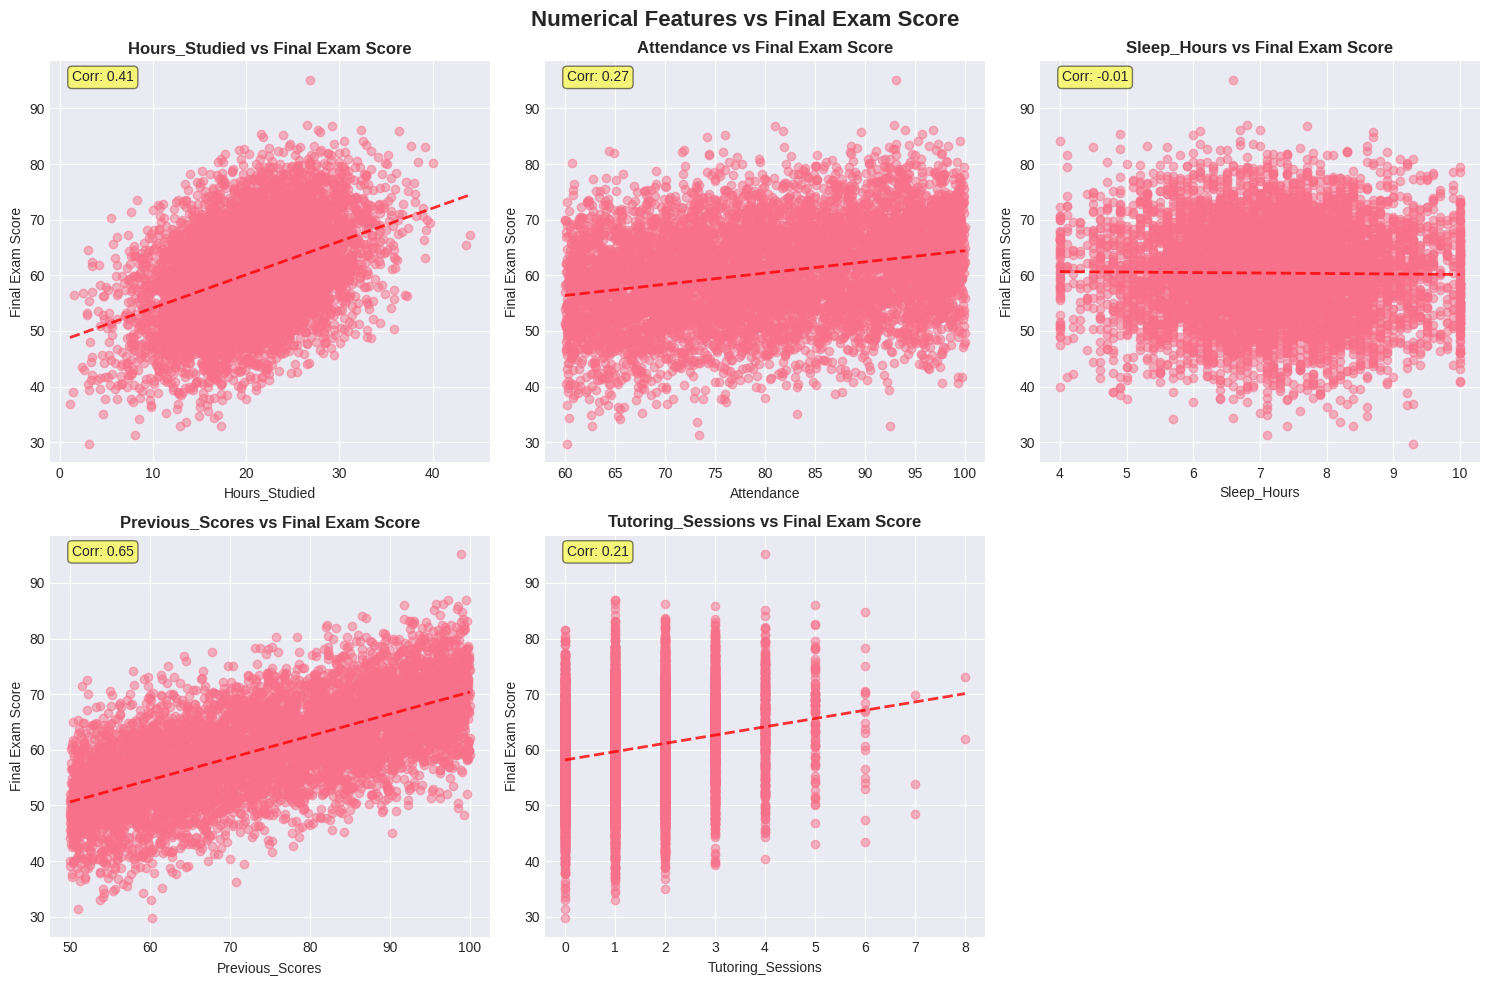

In [10]:

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

# Numerical columns
numerical_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 
                  'Tutoring_Sessions', 'Final_Exam_Score']

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[idx].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.2f}')
    axes[idx].legend()

# Remove empty subplot
if len(numerical_cols) < 12:
    for idx in range(len(numerical_cols), 12):
        fig.delaxes(axes[idx])

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()



# Categorical variables analysis
categorical_cols = ['Parental_Involvement', 'Access_to_Resources', 
                    'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    # Value counts
    counts = df[col].value_counts()
    axes[idx].bar(counts.index, counts.values, alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    
    # Add value labels on bars
    for i, v in enumerate(counts.values):
        axes[idx].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Remove empty subplot
fig.delaxes(axes[5])

plt.suptitle('Distribution of Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()



# Correlation analysis
plt.figure(figsize=(12, 10))

# Encode categorical variables for correlation
df_corr = df.copy()
for col in categorical_cols:
    le = LabelEncoder()
    df_corr[col] = le.fit_transform(df_corr[col])

# Calculate correlation matrix
correlation_matrix = df_corr[numerical_cols + categorical_cols].corr()

# Plot heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix of All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation with target variable
target_corr = correlation_matrix['Final_Exam_Score'].sort_values(ascending=False)
print("\nFeature Correlation with Final Exam Score:")
print(target_corr)



# Box plots for categorical features vs Final Exam Score
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    sns.boxplot(x=col, y='Final_Exam_Score', data=df, ax=axes[idx])
    axes[idx].set_title(f'{col} vs Final Exam Score', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Final Exam Score')

# Remove empty subplot
fig.delaxes(axes[5])

plt.suptitle('Categorical Features Impact on Final Exam Score', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()



# Scatter plots for numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

numerical_cols_without_target = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 
                                  'Previous_Scores', 'Tutoring_Sessions']

for idx, col in enumerate(numerical_cols_without_target):
    axes[idx].scatter(df[col], df['Final_Exam_Score'], alpha=0.5)
    
    # Add trend line
    z = np.polyfit(df[col], df['Final_Exam_Score'], 1)
    p = np.poly1d(z)
    axes[idx].plot(df[col].sort_values(), p(df[col].sort_values()), 
                   "r--", alpha=0.8, linewidth=2)
    
    axes[idx].set_title(f'{col} vs Final Exam Score', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Final Exam Score')
    
    # Add correlation
    corr = df[col].corr(df['Final_Exam_Score'])
    axes[idx].text(0.05, 0.95, f'Corr: {corr:.2f}', transform=axes[idx].transAxes, 
                   fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.5))

# Remove empty subplot
if len(numerical_cols_without_target) < 6:
    for idx in range(len(numerical_cols_without_target), 6):
        fig.delaxes(axes[idx])

plt.suptitle('Numerical Features vs Final Exam Score', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()




# FEATURE ENGINEERING

* **Created interaction features** → capture combined effects (study × attendance, etc.)
* **Added polynomial features** → model non-linear relationships
Generated binned categories → simplify continuous variables
* **Built composite scores** → combine related factors (resources, engagement)
* **Visualized new features** → check their impact on Final_Exam_Score

Feature Engineering Completed!
Original features: 11
Features after engineering: 21

New features created:
- Study_Efficiency
- Attendance_Study_Interaction
- Sleep_Study_Ratio
- Hours_Studied_Squared
- Attendance_Squared
- Previous_Scores_Squared
- Study_Hours_Category
- Attendance_Category
- Resource_Support_Score
- Engagement_Score


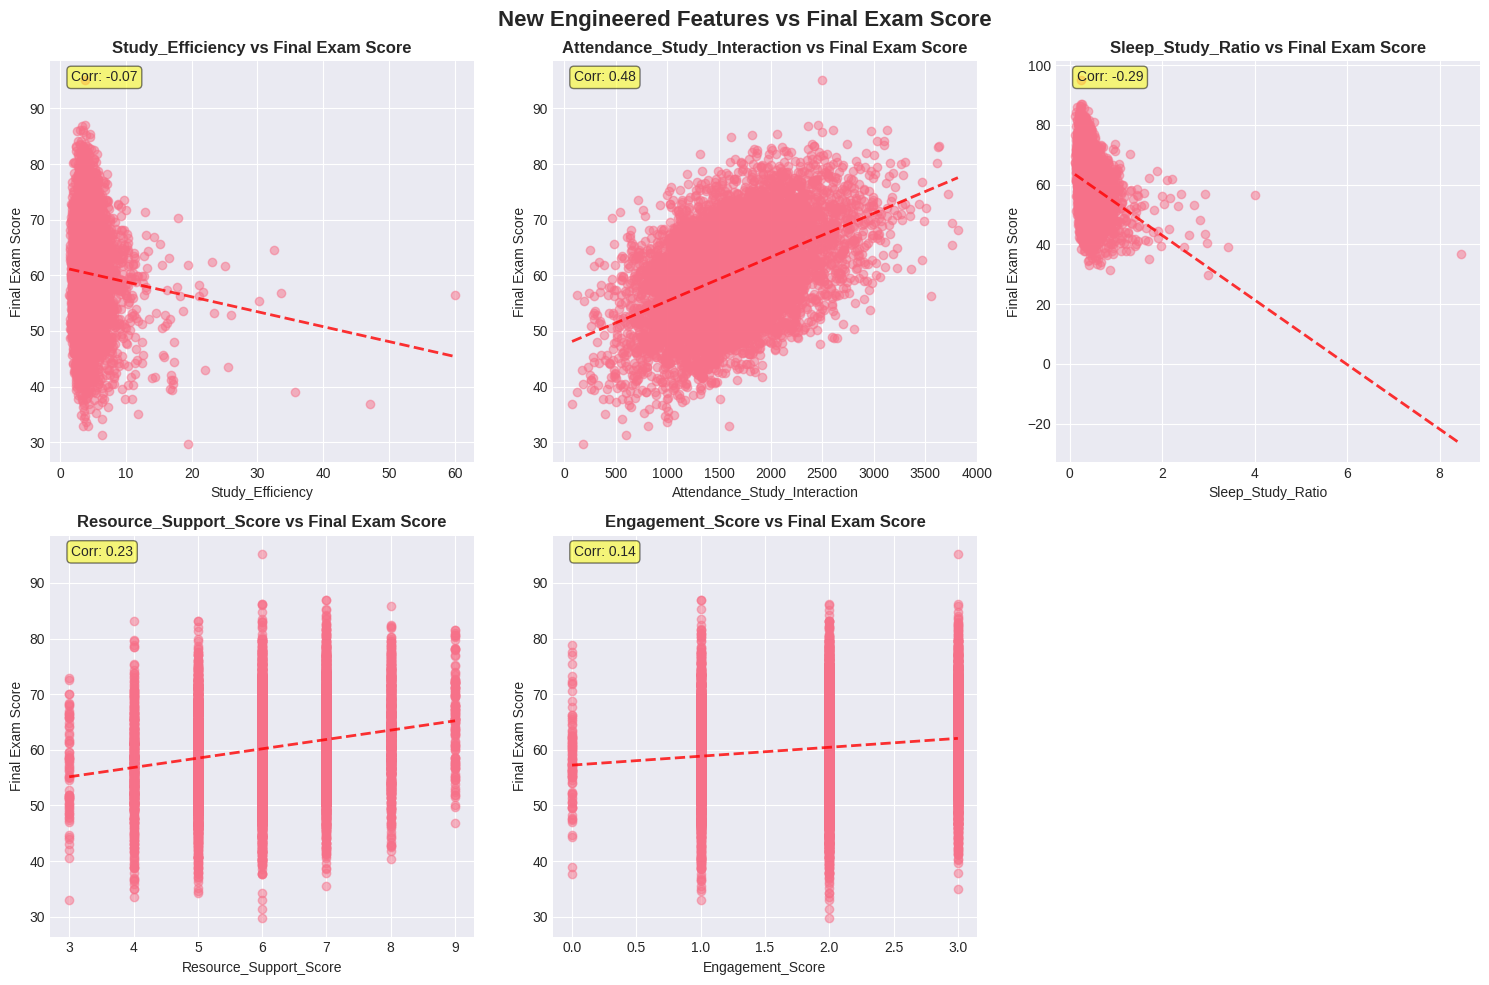

In [11]:

# Create a copy for feature engineering
df_fe = df.copy()

#  Create interaction features
df_fe['Study_Efficiency'] = df_fe['Previous_Scores'] / df_fe['Hours_Studied'].replace(0, 1)
df_fe['Attendance_Study_Interaction'] = df_fe['Attendance'] * df_fe['Hours_Studied']
df_fe['Sleep_Study_Ratio'] = df_fe['Sleep_Hours'] / df_fe['Hours_Studied'].replace(0, 1)

#  Create polynomial features (squared terms)
df_fe['Hours_Studied_Squared'] = df_fe['Hours_Studied'] ** 2
df_fe['Attendance_Squared'] = df_fe['Attendance'] ** 2
df_fe['Previous_Scores_Squared'] = df_fe['Previous_Scores'] ** 2

#  Create binned features
df_fe['Study_Hours_Category'] = pd.cut(df_fe['Hours_Studied'], 
                                        bins=[0, 10, 20, 30, 40], 
                                        labels=['Low', 'Medium', 'High', 'Very High'])
df_fe['Attendance_Category'] = pd.cut(df_fe['Attendance'], 
                                       bins=[0, 60, 75, 90, 100], 
                                       labels=['Poor', 'Average', 'Good', 'Excellent'])

#  Create composite score
df_fe['Resource_Support_Score'] = (
    (df_fe['Parental_Involvement'].map({'Low': 1, 'Medium': 2, 'High': 3})) +
    (df_fe['Access_to_Resources'].map({'Low': 1, 'Medium': 2, 'High': 3})) +
    (df_fe['Motivation_Level'].map({'Low': 1, 'Medium': 2, 'High': 3}))
)

# 2.5 Create engagement score
df_fe['Engagement_Score'] = (
    (df_fe['Extracurricular_Activities'].map({'No': 0, 'Yes': 1})) +
    (df_fe['Internet_Access'].map({'No': 0, 'Yes': 1})) +
    (df_fe['Tutoring_Sessions'] > df_fe['Tutoring_Sessions'].median()).astype(int)
)

print("Feature Engineering Completed!")
print(f"Original features: {df.shape[1]}")
print(f"Features after engineering: {df_fe.shape[1]}")
print("\nNew features created:")
new_features = ['Study_Efficiency', 'Attendance_Study_Interaction', 'Sleep_Study_Ratio',
                'Hours_Studied_Squared', 'Attendance_Squared', 'Previous_Scores_Squared',
                'Study_Hours_Category', 'Attendance_Category', 'Resource_Support_Score',
                'Engagement_Score']
for feat in new_features:
    print(f"- {feat}")




# Visualize new features vs target
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

new_numerical = ['Study_Efficiency', 'Attendance_Study_Interaction', 'Sleep_Study_Ratio',
                 'Resource_Support_Score', 'Engagement_Score']

for idx, col in enumerate(new_numerical):
    axes[idx].scatter(df_fe[col], df_fe['Final_Exam_Score'], alpha=0.5)
    
    # Add trend line
    z = np.polyfit(df_fe[col], df_fe['Final_Exam_Score'], 1)
    p = np.poly1d(z)
    axes[idx].plot(df_fe[col].sort_values(), p(df_fe[col].sort_values()), 
                   "r--", alpha=0.8, linewidth=2)
    
    axes[idx].set_title(f'{col} vs Final Exam Score', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Final Exam Score')
    
    # Add correlation
    corr = df_fe[col].corr(df_fe['Final_Exam_Score'])
    axes[idx].text(0.05, 0.95, f'Corr: {corr:.2f}', transform=axes[idx].transAxes, 
                   fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.5))

# Remove empty subplot
if len(new_numerical) < 6:
    for idx in range(len(new_numerical), 6):
        fig.delaxes(axes[idx])

plt.suptitle('New Engineered Features vs Final Exam Score', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# DATA PREPARATION FOR MODELING

* Selected relevant features and target variable
* Separated **numerical** and **categorica**l columns
* Applied preprocessing:
   - Numerical → imputation + scaling
   - Categorical → imputation + one-hot encoding
* Combined preprocessing using a pipeline
* Split data into **training and testing sets**

In [12]:


# Select features for modeling
features_to_use = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 
                   'Tutoring_Sessions', 'Parental_Involvement', 'Access_to_Resources',
                   'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
                   'Study_Efficiency', 'Attendance_Study_Interaction', 'Sleep_Study_Ratio',
                   'Resource_Support_Score', 'Engagement_Score']

X = df_fe[features_to_use]
y = df_fe['Final_Exam_Score']

# Identify numerical and categorical columns
numerical_features = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 
                      'Tutoring_Sessions', 'Study_Efficiency', 'Attendance_Study_Interaction',
                      'Sleep_Study_Ratio', 'Resource_Support_Score', 'Engagement_Score']

categorical_features = ['Parental_Involvement', 'Access_to_Resources', 
                        'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access']

# Create preprocessing pipelines
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

# Combine preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 5285 samples
Test set size: 1322 samples


#  MODEL TRAINING AND COMPARISON

* **Define Models:**
  - Linear, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting, XGBoost.
* **Pipeline & Training:**
  - Combine preprocessing + model in a Pipeline.
  - Fit each model on training data.
  - Predict on train & test sets.
* **Metrics Computed:**
  - R² Score (train/test)
  - RMSE (test)
  - MAE (test)
* **Cross-Validation:**
  - 5-fold CV for top models: Linear Regression, Random Forest,  Gradient Boosting, XGBoost.
  - Compute mean R² ± 2*std.
* **Model Comparison:**
  - Summarize results in a table.
  - Identify best model based on Test R².
* **Visualization:**
  - Compare Test R², RMSE, and MAE across all models using bar plots.


Linear Regression:
  Train R² Score: 0.7976
  Test R² Score: 0.7918
  Test RMSE: 4.0211
  Test MAE: 3.2289

Ridge Regression:
  Train R² Score: 0.7976
  Test R² Score: 0.7918
  Test RMSE: 4.0213
  Test MAE: 3.2291

Lasso Regression:
  Train R² Score: 0.7077
  Test R² Score: 0.7036
  Test RMSE: 4.7980
  Test MAE: 3.8104

Decision Tree:
  Train R² Score: 1.0000
  Test R² Score: 0.5214
  Test RMSE: 6.0966
  Test MAE: 4.8181

Random Forest:
  Train R² Score: 0.9649
  Test R² Score: 0.7586
  Test RMSE: 4.3295
  Test MAE: 3.4494

Gradient Boosting:
  Train R² Score: 0.8178
  Test R² Score: 0.7833
  Test RMSE: 4.1020
  Test MAE: 3.2803

XGBoost:
  Train R² Score: 0.9588
  Test R² Score: 0.7432
  Test RMSE: 4.4655
  Test MAE: 3.5603
CROSS-VALIDATION RESULTS (5-Fold)

Linear Regression:
  CV R² Scores: [0.78285619 0.79241156 0.80340769 0.8092343  0.79045392]
  Mean CV R²: 0.7957 (+/- 0.0189)

Random Forest:
  CV R² Scores: [0.73784421 0.74789436 0.75303047 0.76462843 0.74508503]
  Mean CV R²: 

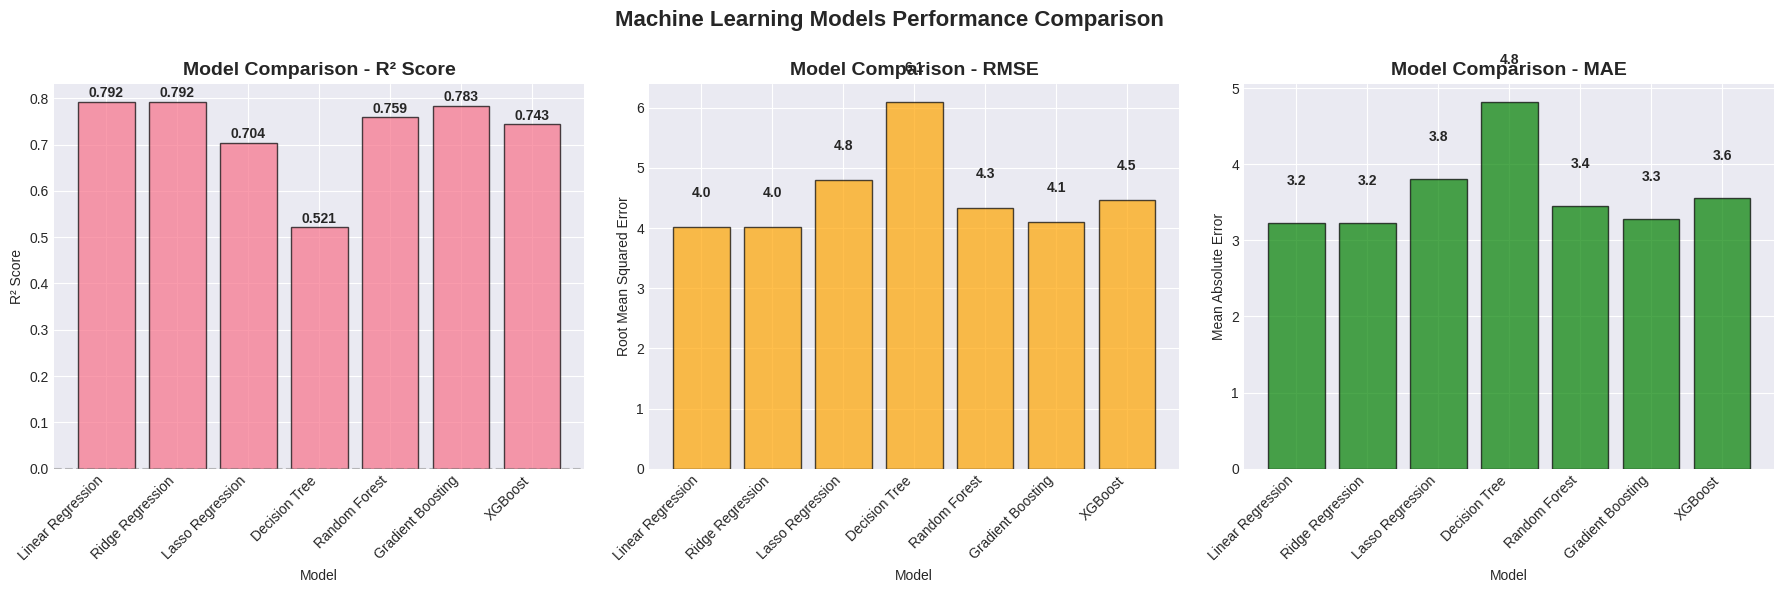

In [13]:

# Define models to evaluate
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42, n_estimators=100),
    'XGBoost': XGBRegressor(random_state=42, n_estimators=100, verbosity=0)
}

# Train and evaluate models
results = {}
predictions = {}

for name, model in models.items():
    # Create pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Train the model
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    # Store results
    results[name] = {
        'Train R²': train_r2,
        'Test R²': test_r2,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae
    }
    predictions[name] = y_pred_test
    
    print(f"\n{name}:")
    print(f"  Train R² Score: {train_r2:.4f}")
    print(f"  Test R² Score: {test_r2:.4f}")
    print(f"  Test RMSE: {test_rmse:.4f}")
    print(f"  Test MAE: {test_mae:.4f}")



# Cross-validation for top models

print("CROSS-VALIDATION RESULTS (5-Fold)")


cv_results = {}
for name in ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']:
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', models[name])
    ])
    
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
    cv_results[name] = cv_scores
    
    print(f"\n{name}:")
    print(f"  CV R² Scores: {cv_scores}")
    print(f"  Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


# Create comparison dataframe
results_df = pd.DataFrame(results).T
print("\nMODEL COMPARISON SUMMARY:")
print(results_df.round(4))

# Find best model
best_model = results_df['Test R²'].idxmax()
print(f"\n Best Model: {best_model}")
print(f"   Test R² Score: {results_df.loc[best_model, 'Test R²']:.4f}")
print(f"   Test RMSE: {results_df.loc[best_model, 'Test RMSE']:.4f}")


# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# R² Score comparison
ax1 = axes[0]
bars1 = ax1.bar(results_df.index, results_df['Test R²'], alpha=0.7, edgecolor='black')
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_title('Model Comparison - R² Score', fontsize=14, fontweight='bold')
ax1.set_xlabel('Model')
ax1.set_ylabel('R² Score')
ax1.set_xticklabels(results_df.index, rotation=45, ha='right')
for bar, val in zip(bars1, results_df['Test R²']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', fontweight='bold')

# RMSE comparison
ax2 = axes[1]
bars2 = ax2.bar(results_df.index, results_df['Test RMSE'], alpha=0.7, edgecolor='black', color='orange')
ax2.set_title('Model Comparison - RMSE', fontsize=14, fontweight='bold')
ax2.set_xlabel('Model')
ax2.set_ylabel('Root Mean Squared Error')
ax2.set_xticklabels(results_df.index, rotation=45, ha='right')
for bar, val in zip(bars2, results_df['Test RMSE']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val:.1f}', ha='center', fontweight='bold')

# MAE comparison
ax3 = axes[2]
bars3 = ax3.bar(results_df.index, results_df['Test MAE'], alpha=0.7, edgecolor='black', color='green')
ax3.set_title('Model Comparison - MAE', fontsize=14, fontweight='bold')
ax3.set_xlabel('Model')
ax3.set_ylabel('Mean Absolute Error')
ax3.set_xticklabels(results_df.index, rotation=45, ha='right')
for bar, val in zip(bars3, results_df['Test MAE']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val:.1f}', ha='center', fontweight='bold')

plt.suptitle('Machine Learning Models Performance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


#  FEATURE IMPORTANCE ANALYSIS (Random Forest)

**Trains Random Forest, extracts and visualizes the most influential features after preprocessing to see which factors drive predictions.**


TOP 10 MOST IMPORTANT FEATURES:
                         Feature  Importance
3                Previous_Scores    0.474131
6   Attendance_Study_Interaction    0.263348
4              Tutoring_Sessions    0.043026
8         Resource_Support_Score    0.036611
1                     Attendance    0.032616
15          Motivation_Level_Low    0.025186
7              Sleep_Study_Ratio    0.024178
2                    Sleep_Hours    0.023848
5               Study_Efficiency    0.020565
0                  Hours_Studied    0.018105


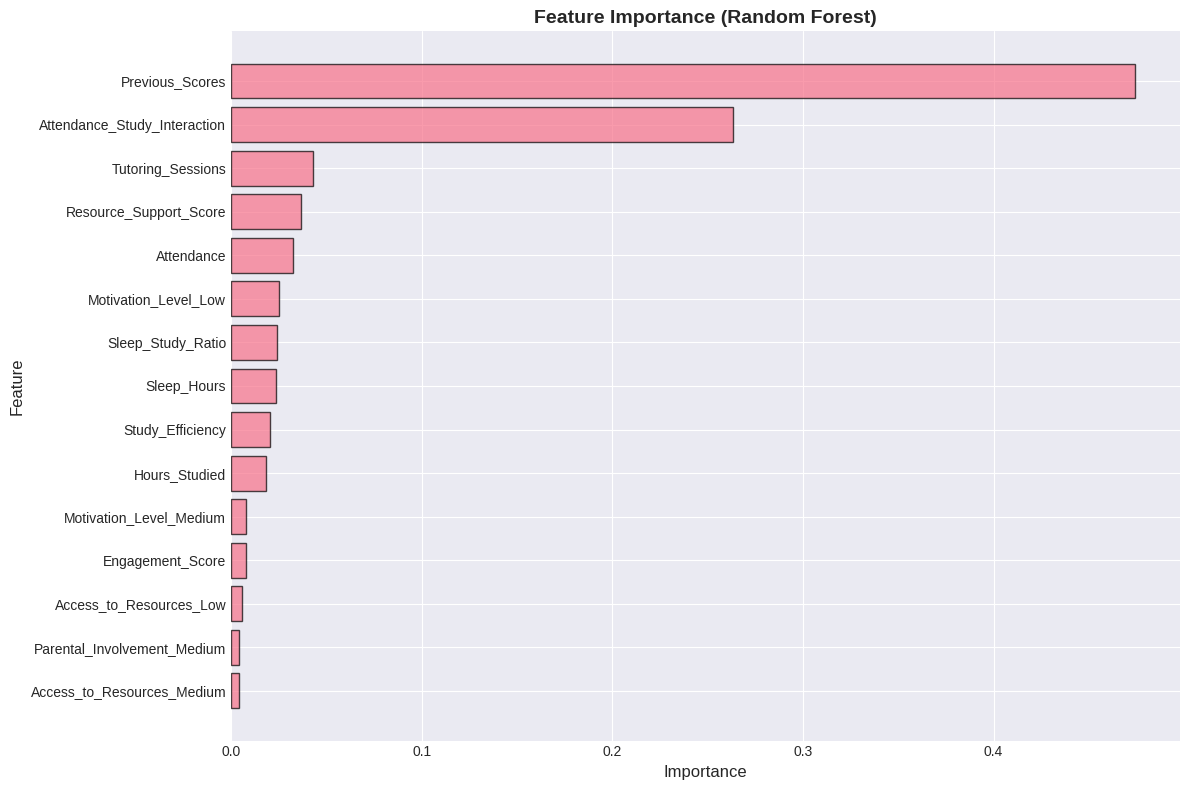

In [14]:

# Train Random Forest with preprocessor to get feature importance
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_estimators=100))
])
pipeline_rf.fit(X_train, y_train)

# Get feature names after preprocessing
feature_names = (numerical_features + 
                 list(pipeline_rf.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .named_steps['onehot']
                      .get_feature_names_out(categorical_features)))

# Get feature importances
importances = pipeline_rf.named_steps['regressor'].feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nTOP 10 MOST IMPORTANT FEATURES:")
print(feature_importance_df.head(10))

# Visualize feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance_df.head(15)
plt.barh(top_features['Feature'], top_features['Importance'], alpha=0.7, edgecolor='black')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



#  HYPERPARAMETER TUNING FOR BEST MODEL

**Optimizes Gradient Boosting hyperparameters with grid search, then evaluates the best model on test data for performance improvement**

In [15]:

# Define parameter grid for Gradient Boosting
param_grid = {
    'regressor__n_estimators': [50, 100, 150],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__max_depth': [3, 5, 7],
    'regressor__min_samples_split': [2, 5, 10]
}

# Create pipeline for Gradient Boosting
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

# Perform Grid Search
grid_search = GridSearchCV(gb_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation R² Score: {grid_search.best_score_:.4f}")

# Evaluate best model on test set
best_model_tuned = grid_search.best_estimator_
y_pred_tuned = best_model_tuned.predict(X_test)
test_r2_tuned = r2_score(y_test, y_pred_tuned)
test_rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print(f"\nTuned Model Test Performance:")
print(f"  Test R² Score: {test_r2_tuned:.4f}")
print(f"  Test RMSE: {test_rmse_tuned:.4f}")


Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best Parameters: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 100}
Best Cross-Validation R² Score: 0.7813

Tuned Model Test Performance:
  Test R² Score: 0.7834
  Test RMSE: 4.1012


# PREDICTIONS VS ACTUAL VISUALIZATION

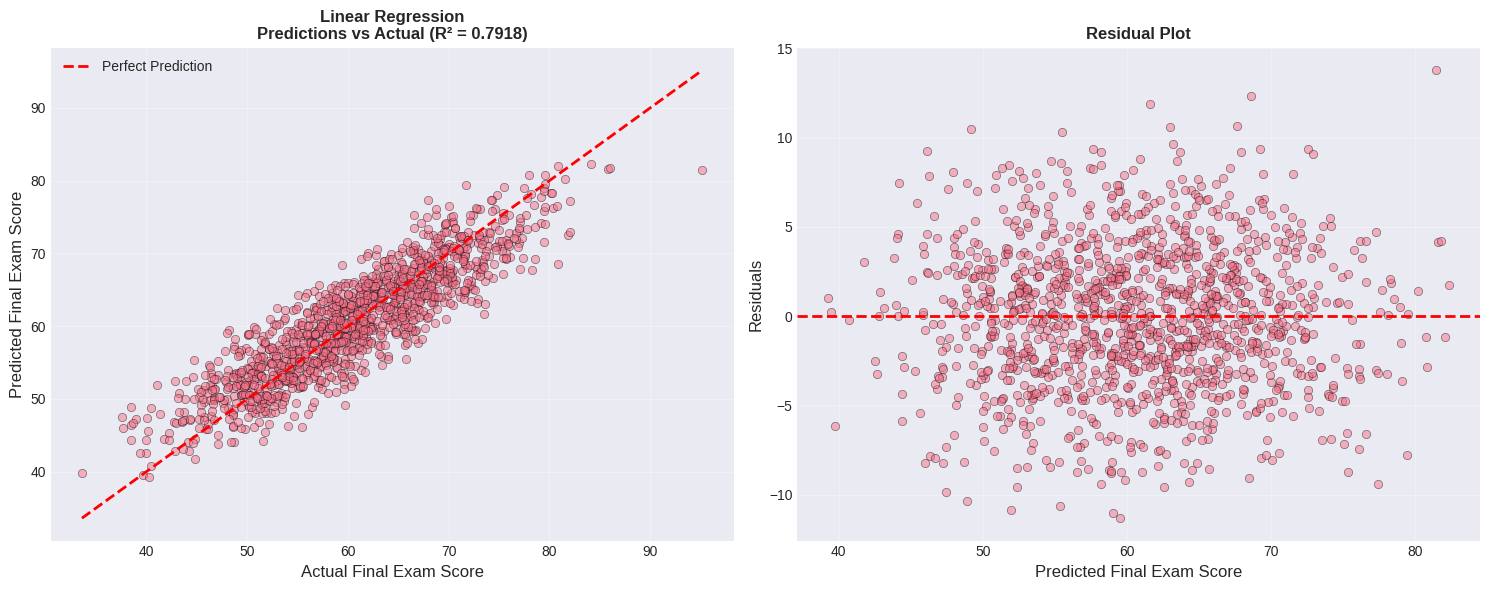

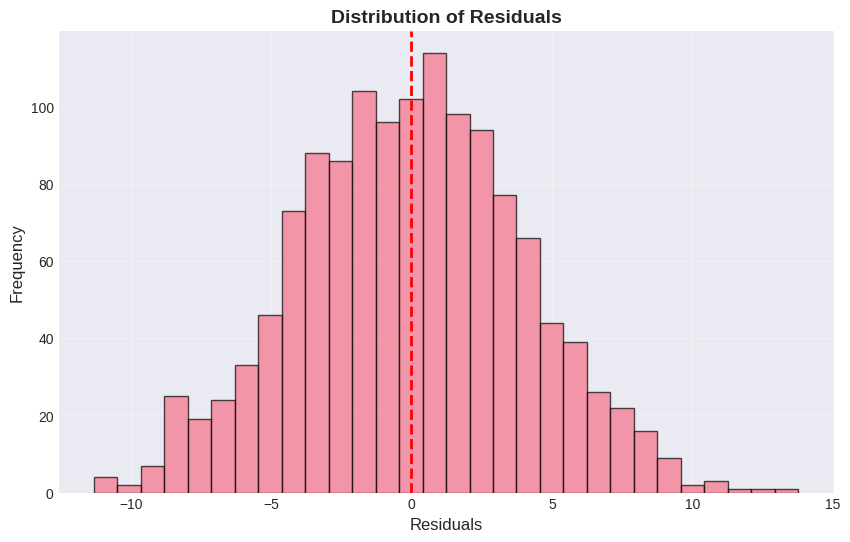


Residuals Statistics:
Mean of residuals: -0.0418
Std of residuals: 4.0224


In [16]:

# Get predictions from best model
best_model_name = best_model
best_predictions = predictions[best_model_name]

# Create scatter plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Predictions vs Actual
ax1 = axes[0]
ax1.scatter(y_test, best_predictions, alpha=0.5, edgecolors='black', linewidth=0.5)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Final Exam Score', fontsize=12)
ax1.set_ylabel('Predicted Final Exam Score', fontsize=12)
ax1.set_title(f'{best_model_name}\nPredictions vs Actual (R² = {results_df.loc[best_model_name, "Test R²"]:.4f})', 
              fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Residuals
ax2 = axes[1]
residuals = y_test - best_predictions
ax2.scatter(best_predictions, residuals, alpha=0.5, edgecolors='black', linewidth=0.5)
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Predicted Final Exam Score', fontsize=12)
ax2.set_ylabel('Residuals', fontsize=12)
ax2.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Residual distribution
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Residuals', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nResiduals Statistics:")
print(f"Mean of residuals: {residuals.mean():.4f}")
print(f"Std of residuals: {residuals.std():.4f}")



In [17]:





print("\n MODEL PERFORMANCE:")
print(f" Best Model: {best_model} with R² = {results_df.loc[best_model, 'Test R²']:.4f}")


print("\n MOST IMPORTANT FEATURES:")
for idx, row in feature_importance_df.head(5).iterrows():
    print(f"   {row['Feature']}: {row['Importance']:.4f}")




 MODEL PERFORMANCE:
 Best Model: Linear Regression with R² = 0.7918

 MOST IMPORTANT FEATURES:
   Previous_Scores: 0.4741
   Attendance_Study_Interaction: 0.2633
   Tutoring_Sessions: 0.0430
   Resource_Support_Score: 0.0366
   Attendance: 0.0326


# Overall Summary

In this project, we analyze student performance data to predict final exam scores and understand the factors that influence academic success.

**What we do:**

* Explore the dataset with visualizations and summary statistics to understand distributions, correlations, and relationships between features and exam scores.
* Perform feature engineering by creating interaction terms, polynomial features, and composite scores (like engagement and resource support) to better capture patterns in the data.
* Train and evaluate multiple machine learning models (Linear, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting, XGBoost) using metrics like R², RMSE, and MAE.
* Tune model parameters using Grid Search to optimize performance.
* Analyze feature importance to identify which factors most influence student outcomes.

**Why we do it:**

* To provide data-driven insights for educators and policymakers.
* To identify key drivers of student success (like previous scores, study habits, attendance, and engagement).
* To enable personalized interventions for students at risk of low performance.

**What can be done:**

* Use the best-performing model to predict future student scores and monitor progress.
* Apply insights to improve teaching strategies, study programs, and resource allocation.
* Continuously update models with new data to refine predictions and recommendations.